# REGULARISATION

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns 


In [2]:
ds = pd.read_csv('car_dataset.csv')
x = ds.iloc[:,:-1]
y = ds['selling_price']

In [3]:
x = ds['car_name']
# To delete columns from a dataset, use the drop() method with axis=1.
# For example, to delete the 'car_name' column:
de = ds.drop('car_name', axis=1, inplace=True)

print(de)

None


In [4]:
x = ds['transmission']
# To delete columns from a dataset, use the drop() method with axis=1.
# For example, to delete the 'transmission' column:
de = ds.drop('transmission', axis=1, inplace=True)

In [5]:
x = ds['fuel_type']
# To delete columns from a dataset, use the drop() method with axis=1.
# For example, to delete the 'car_name' column:
de = ds.drop('fuel_type', axis=1, inplace=True)

In [6]:
ds.head(3)

,year,present_price,driven_kms,owner,selling_price
0,2018,9.5,35000,1,7.8
1,2017,8.2,42000,1,6.5
2,2019,25.0,20000,0,22.0


In [7]:
x = ds.iloc[:,:-1]
y = ds['selling_price']


In [8]:
sc = StandardScaler()
sc.fit(x)
x = pd.DataFrame(sc.transform(x), columns= x.columns)
x

,year,present_price,driven_kms,owner
0,-0.939262,-0.447317,0.789104,0.927047
1,-1.596151,-0.651535,1.356100,0.927047
2,-0.282373,1.987586,-0.425889,-1.005758
3,-2.253041,-0.714371,2.004096,2.859852
4,0.374516,-0.918589,-0.830886,0.927047
...,...,...,...,...
216,1.031405,-0.337354,-1.235884,-1.005758
217,-0.939262,0.495226,1.599099,0.927047
218,-0.282373,-0.840043,0.384106,0.927047
219,0.374516,-0.243099,-0.425889,-1.005758


In [9]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge

In [10]:
x_train, x_test , y_train ,y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [11]:
lr = LinearRegression()
lr.fit(x_train,y_train)
lr.score(x_test, y_test)*100

99.8643103256175

#   lasso

In [12]:
la = Lasso(alpha=0.1)
la.fit(x_train, y_train)
la.score(x_test, y_test)*100

99.75469453019302

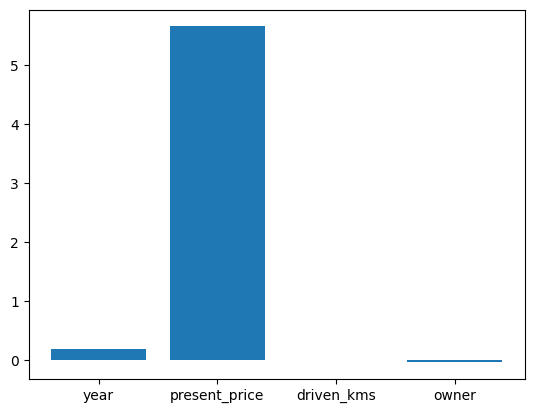

In [13]:
plt.bar(x.columns, la.coef_)
plt.show()

# RIDGE

In [14]:
r = Ridge(alpha=0.1)
r.fit(x_train, y_train)
r.score(x_test, y_test)*100

99.86345497496869

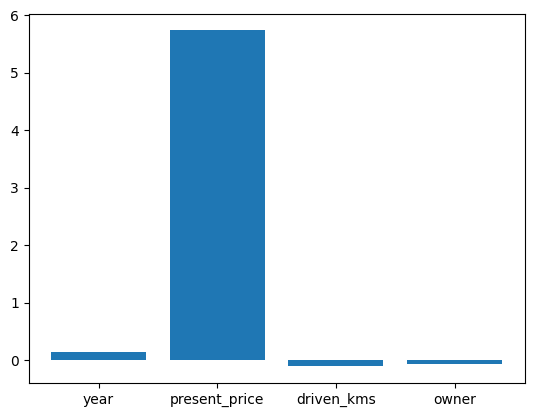

In [15]:
plt.bar(x.columns, r.coef_)
plt.show()

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
import numpy as np

In [17]:
mean_absolute_error(y_test, lr.predict(x_test))


0.15117268843960918

In [18]:
mean_squared_error(y_test, lr.predict(x_test))

0.04303209397642173

In [19]:
print(np.sqrt(mean_squared_error(y_test, lr.predict(x_test))))

0.2074417845479105


In [20]:
df = pd.DataFrame({'col_names':x_train.columns, 'LinearRegression':lr.coef_, 'Lasso':la.coef_, 'Ridge':r.coef_})
# In Lasso and Ridge regression, coefficients closer to zero indicate that the model is regularizing (shrinking) less important features.
# This is generally good as it helps reduce overfitting and highlights the most relevant features.
# However, if all coefficients are very close to zero, it may indicate too much regularization (underfitting).
df

,col_names,LinearRegression,Lasso,Ridge
0,year,0.143237,0.186619,0.146238
1,present_price,5.742759,5.657225,5.738800
2,driven_kms,-0.112845,-0.008930,-0.110178
3,owner,-0.069063,-0.042147,-0.069855


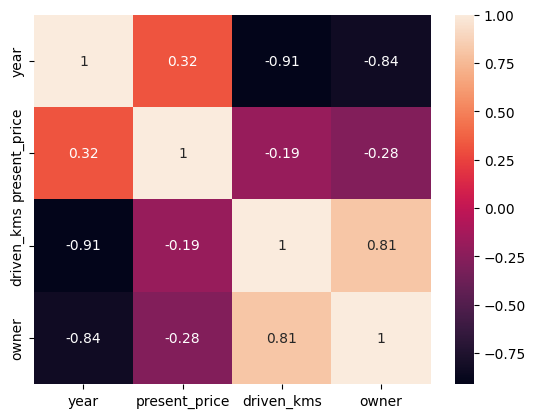

In [21]:
sns.heatmap(x.corr(), annot=True)
plt.show()